In [79]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score,\
    f1_score, roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GroupShuffleSplit,\
    GroupKFold, GridSearchCV, RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from sklearn import svm
from sklearn.svm import SVC
import lightgbm as lgb
import xgboost 

In [42]:
import os
import warnings
import pandas as pd
import features as f
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
import statistics

warnings.filterwarnings('ignore')

parent = os.path.dirname(os.getcwd())

data = pd.read_csv(parent+"\\data\\MEM_Features_01.csv")
data.drop("Unnamed: 0", inplace=True, axis=1)
data.head()

,LISTID,PRESENTED_WORD,PRESENT_POSITION,HIT,PARTICIPANT_GROUP,MOST_SIM_VAL,MOST_SIM_DIST,AVG_SIM_PREV_2,AVG_CONTRAST_3,PREV_SIM,PRESENT_ZONE,P_ID
0,1,KALEM,1,1,soc,NaN,NaN,NaN,0.525725,NaN,1,soc9
1,1,ÖLÇEK,2,0,soc,0.338901,1.0,0.338901,0.557002,0.338901,1,soc9
2,1,ÇANTA,3,0,soc,0.352932,2.0,0.297480,0.532265,0.242028,1,soc9
3,1,AĞAÇ,4,1,soc,0.383445,2.0,0.382491,0.407015,0.381538,1,soc9
4,1,PARK,5,0,soc,0.428213,1.0,0.385916,0.520172,0.428213,2,soc9


In [43]:
#FOR NOW, FILLING THESE IN WITH WHAT I THINK TO BE FIT 
#WILL EDIT, BUT I JUST REPLACE WITH MEAN TO NOT DISTURB THE DISTRIBUTION
#MAYBE WE CAN DO THIS: USE PARTICIPANT WIDE SIM CALCULATIONS, SO WE HAVE LESS NA.
#AND ON PREV WE CAN TURN INTO AVG_SIM, WHICH WILL INCLUDE LATER WORDS AS WELL
for col in data.columns:
    if data[col].isna().sum() > 0: 
        data[col] = data[col].fillna(np.mean(data[col]))
data.isna().sum()

LISTID               0
PRESENTED_WORD       0
PRESENT_POSITION     0
HIT                  0
PARTICIPANT_GROUP    0
MOST_SIM_VAL         0
MOST_SIM_DIST        0
AVG_SIM_PREV_2       0
AVG_CONTRAST_3       0
PREV_SIM             0
PRESENT_ZONE         0
P_ID                 0
dtype: int64

In [44]:
cols_categorical = ["LISTID", "PARTICIPANT_GROUP", "PRESENT_ZONE"]
cols_numeric = ["PRESENT_POSITION", "MOST_SIM_VAL", "MOST_SIM_DIST",
                "AVG_SIM_PREV_2", "AVG_CONTRAST_3", "PREV_SIM"]
target = data["HIT"]
data = data.drop(["HIT", "PRESENTED_WORD"], axis = 1)

In [ ]:
X_df = data[cols_categorical + cols_numeric]
encoder = OneHotEncoder()

X_encoded = encoder.fit_transform(X_df[cols_categorical]).toarray()
encoded_feature_names = encoder.get_feature_names_out(cols_categorical)
encoded_feature_names = list(encoded_feature_names)

X_numeric = X_df[cols_numeric]

X_df = np.hstack([X_encoded, X_numeric])
X_df = pd.DataFrame(data = X_df, columns=encoded_feature_names+cols_numeric)

X_df

,LISTID_1,LISTID_2,LISTID_3,LISTID_4,PARTICIPANT_GROUP_eng,PARTICIPANT_GROUP_soc,PRESENT_ZONE_1,PRESENT_ZONE_2,PRESENT_ZONE_3,PRESENT_POSITION,MOST_SIM_VAL,MOST_SIM_DIST,AVG_SIM_PREV_2,AVG_CONTRAST_3,PREV_SIM
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.435830,4.853497,0.333815,0.525725,0.333565
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,0.338901,1.000000,0.338901,0.557002,0.338901
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,0.352932,2.000000,0.297480,0.532265,0.242028
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,4.0,0.383445,2.000000,0.382491,0.407015,0.381538
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,0.428213,1.000000,0.385916,0.520172,0.428213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3031,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,13.0,0.496363,6.000000,0.367762,0.477837,0.381177
3032,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,14.0,0.384075,11.000000,0.312756,0.582317,0.369045
3033,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,15.0,0.405587,4.000000,0.254575,0.598769,0.222042
3034,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,16.0,0.428927,15.000000,0.298563,0.567147,0.339570


In [93]:
def Overviewer(estimator, param_grid, X_df, target, data, scoring = "recall", search = "grid"):
    """
    Blueprint function that acts like a pipeline
    estimator: function like SVC or KNearestNeighbors
    compares SMOTENC, SMOTEEEN, SMOTETomek, RandomUnderSampling
    """   
    groups = data["P_ID"].values
    y = target.values
    X = X_df.values

    # Split logic remains intact
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups))
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]

    cols_categorical_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8] 

    # 1. Initialize the base SMOTENC to handle the categorical indices
    base_smotenc = SMOTENC(categorical_features=cols_categorical_indices, random_state=42)

    # 2. Map all strategies into a dictionary. 
    # SMOTEENN and SMOTETomek require the base_smotenc object to handle mixed data correctly.
    samplers = {
        "SMOTENC": base_smotenc,
        "SMOTEENN": SMOTEENN(smote=base_smotenc, random_state=42),
        "SMOTETomek": SMOTETomek(smote=base_smotenc, random_state=42),
        "RandomUnderSampling": RandomUnderSampler(random_state=42)
    }

    gkf = GroupKFold(n_splits=3)
    
    # Optional: Consolidate ROC curves onto a single plot for easy comparison
    fig, ax = plt.subplots(figsize=(7.5, 6))

    # 3. Iterate through samplers to keep the pipeline DRY (Don't Repeat Yourself)
    for name, sampler in samplers.items():
        print(f"\n==========================================")
        print(f"=== {name.upper()} ===")
        print(f"==========================================")

        pipeline = ImbPipeline([
            ('sampler', sampler),
            ('scaler', StandardScaler()),
            ('estimator', estimator)
        ])

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=gkf,
            scoring=scoring, 
            n_jobs=-1
        )

        random_search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            cv=gkf,
            scoring=scoring, 
            n_jobs=-1,
            n_iter= 100
        )

        if search == "random":
            random_search.fit(X_train, y_train, groups=groups_train)
            best_model = random_search.best_estimator_

        if search == "grid":
            grid_search.fit(X_train, y_train, groups=groups_train)
            best_model = grid_search.best_estimator_
        
        y_pred_train = best_model.predict(X_train)
        y_pred_test = best_model.predict(X_test)

        print("=== TRAIN PERFORMANCE ===")
        print("Accuracy:", accuracy_score(y_train, y_pred_train))
        print(classification_report(y_train, y_pred_train))

        print("=== TEST PERFORMANCE ===")
        print("Accuracy:", accuracy_score(y_test, y_pred_test))
        print(classification_report(y_test, y_pred_test))
        
        # Overlay the ROC curve for this specific sampler on the shared axis
        RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax, name=name)
        
    plt.title("ROC Curves across Resampling Strategies")
    plt.show()



=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.7763975155279503
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1621
           1       0.65      0.69      0.67       794

    accuracy                           0.78      2415
   macro avg       0.75      0.75      0.75      2415
weighted avg       0.78      0.78      0.78      2415

=== TEST PERFORMANCE ===
Accuracy: 0.5942028985507246
              precision    recall  f1-score   support

           0       0.72      0.69      0.70       437
           1       0.33      0.38      0.35       184

    accuracy                           0.59       621
   macro avg       0.53      0.53      0.53       621
weighted avg       0.61      0.59      0.60       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.5797101449275363
              precision    recall  f1-score   support

           0       0.76      0.54      0.63      1621
           1       0.41      0.65     

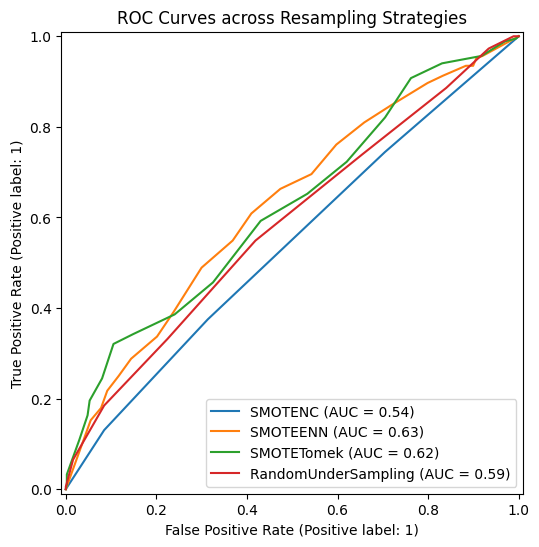

In [70]:
knn = KNeighborsClassifier()
param_grid = {
    'estimator__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'estimator__weights': ['uniform', 'distance'],        
    'estimator__metric': ['euclidean', 'manhattan']      
}
Overviewer(knn, param_grid, X_df, target, data)


=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.5834368530020704
              precision    recall  f1-score   support

           0       0.73      0.60      0.66      1621
           1       0.40      0.54      0.46       794

    accuracy                           0.58      2415
   macro avg       0.57      0.57      0.56      2415
weighted avg       0.62      0.58      0.59      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6473429951690821
              precision    recall  f1-score   support

           0       0.80      0.67      0.73       437
           1       0.43      0.60      0.50       184

    accuracy                           0.65       621
   macro avg       0.61      0.63      0.61       621
weighted avg       0.69      0.65      0.66       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.5664596273291925
              precision    recall  f1-score   support

           0       0.73      0.55      0.63      1621
           1       0.39      0.59     

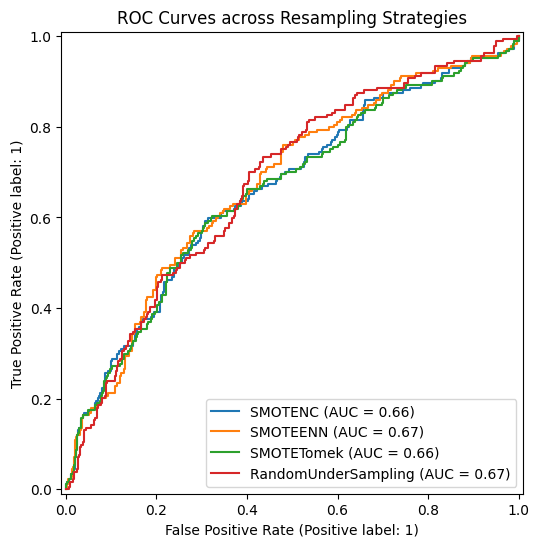

In [71]:
nb = GaussianNB()
param_grid = {}
Overviewer(nb, param_grid, X_df, target, data)


=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.5362318840579711
              precision    recall  f1-score   support

           0       0.74      0.48      0.58      1621
           1       0.38      0.66      0.48       794

    accuracy                           0.54      2415
   macro avg       0.56      0.57      0.53      2415
weighted avg       0.62      0.54      0.55      2415

=== TEST PERFORMANCE ===
Accuracy: 0.5748792270531401
              precision    recall  f1-score   support

           0       0.78      0.55      0.64       437
           1       0.37      0.64      0.47       184

    accuracy                           0.57       621
   macro avg       0.58      0.59      0.56       621
weighted avg       0.66      0.57      0.59       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.3287784679089027
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1621
           1       0.33      1.00     

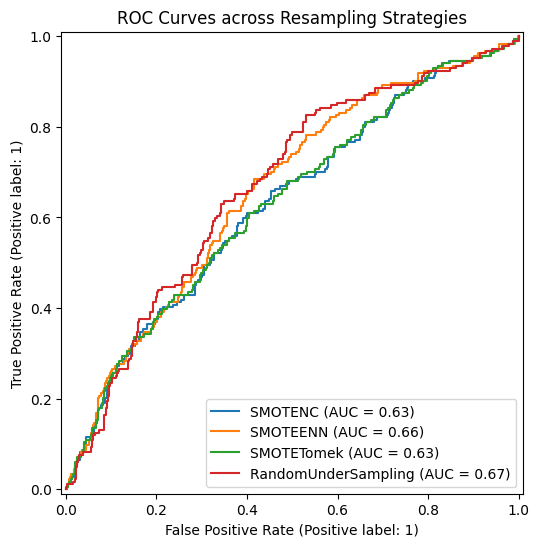

In [72]:
radial = SVC(kernel="rbf")
param_grid = {
    'estimator__C': [0.1, 1, 10, 100],
    'estimator__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}
Overviewer(radial, param_grid, X_df, target, data)



=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6811594202898551
              precision    recall  f1-score   support

           0       0.73      0.83      0.78      1621
           1       0.52      0.37      0.43       794

    accuracy                           0.68      2415
   macro avg       0.63      0.60      0.61      2415
weighted avg       0.66      0.68      0.66      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6988727858293076
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       437
           1       0.49      0.39      0.44       184

    accuracy                           0.70       621
   macro avg       0.63      0.61      0.61       621
weighted avg       0.68      0.70      0.69       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6178053830227743
              precision    recall  f1-score   support

           0       0.76      0.63      0.69      1621
           1       0.44      0.60     

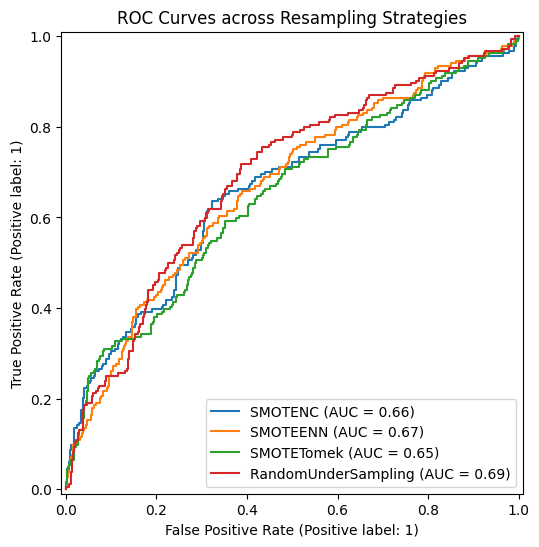

In [78]:
polynomial = SVC(kernel="poly", max_iter=10000)
param_grid = {
    'estimator__C': [0.1, 1, 10, 100],
    'estimator__degree': [2, 3],
    'estimator__gamma': ['scale', 0.01, 0.1, 1],
    'estimator__coef0': [0, 1, 2]
}
Overviewer(polynomial, param_grid, X_df, target, data, "f1_macro")


=== SMOTENC ===
[LightGBM] [Info] Number of positive: 1621, number of negative: 1621
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000345 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1132
[LightGBM] [Info] Number of data points in the train set: 3242, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
=== TRAIN PERFORMANCE ===
Accuracy: 0.7300207039337474
              precision    recall  f1-score   support

           0       0.76      0.87      0.81      1621
           1       0.63      0.44      0.52       794

    accuracy                           0.73      2415
   macro avg       0.69      0.66      0.67      2415
weighted avg       0.72      0.73      0.72      2415

=== TEST PERFORMANCE ===
Accuracy: 0.714975845410628
              precision    recall  f1-score   su

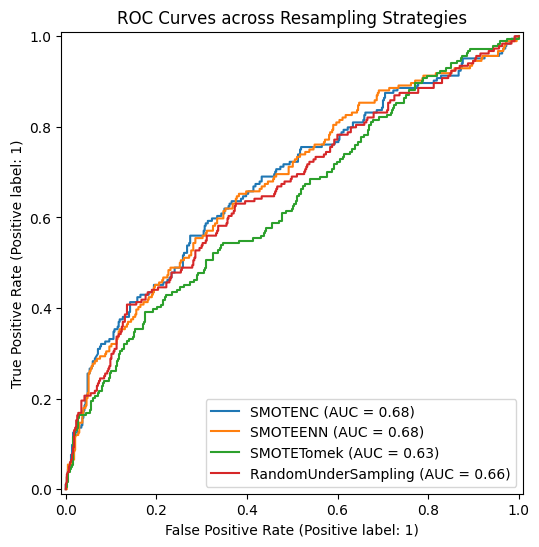

In [89]:
lgbm = lgb.LGBMClassifier()
param_grid = {
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__n_estimators': [100, 500, 1000],
    'estimator__num_leaves': [31, 63, 127],
    'estimator__max_depth': [-1, 5, 8],
    'estimator__min_child_samples': [10, 20, 30],
    'estimator__subsample': [0.7, 0.8, 1.0],
    'estimator__colsample_bytree': [0.7, 0.8, 1.0]
}

Overviewer(lgbm, param_grid, X_df, target, data, scoring="f1_macro", search="random")



=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.7656314699792961
              precision    recall  f1-score   support

           0       0.80      0.87      0.83      1621
           1       0.68      0.54      0.60       794

    accuracy                           0.77      2415
   macro avg       0.74      0.71      0.72      2415
weighted avg       0.76      0.77      0.76      2415

=== TEST PERFORMANCE ===
Accuracy: 0.677938808373591
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       437
           1       0.45      0.42      0.44       184

    accuracy                           0.68       621
   macro avg       0.61      0.60      0.61       621
weighted avg       0.67      0.68      0.67       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6480331262939959
              precision    recall  f1-score   support

           0       0.78      0.66      0.72      1621
           1       0.47      0.61      

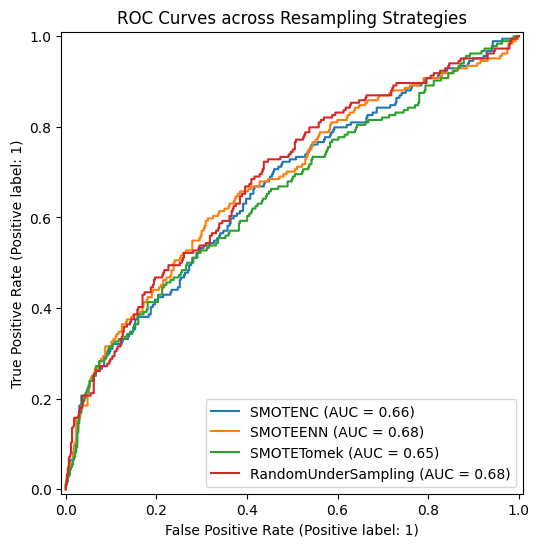

In [94]:
from random import randint, uniform
xgb = xgboost.XGBClassifier()
param_grid = {
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__n_estimators': [100, 200, 500],
    'estimator__max_depth': [3, 5, 7],
    'estimator__min_child_weight': [1, 3, 5],
    'estimator__subsample': [0.7, 0.8, 1.0],
    'estimator__colsample_bytree': [0.7, 0.8, 1.0],
    'estimator__gamma': [0, 0.1, 0.2]
}
Overviewer(xgb, param_grid, X_df, target, data, "f1_macro","random")


=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6157349896480331
              precision    recall  f1-score   support

           0       0.76      0.63      0.69      1621
           1       0.44      0.59      0.50       794

    accuracy                           0.62      2415
   macro avg       0.60      0.61      0.59      2415
weighted avg       0.65      0.62      0.63      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6215780998389694
              precision    recall  f1-score   support

           0       0.80      0.62      0.70       437
           1       0.41      0.62      0.49       184

    accuracy                           0.62       621
   macro avg       0.60      0.62      0.60       621
weighted avg       0.68      0.62      0.64       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.4977225672877847
              precision    recall  f1-score   support

           0       0.80      0.33      0.47      1621
           1       0.38      0.83     

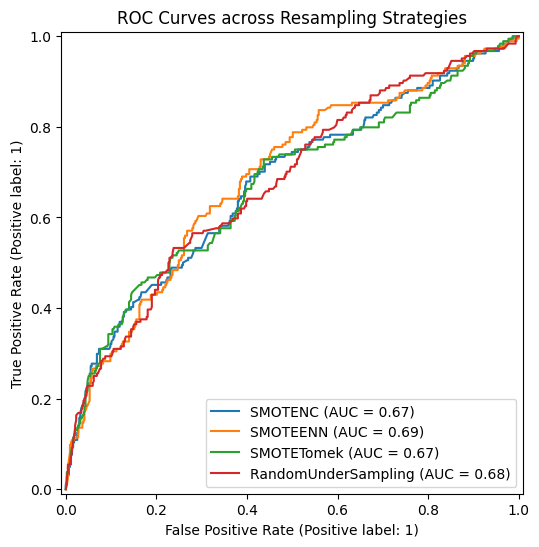

In [95]:
Overviewer(xgb, param_grid, X_df, target, data, "recall", "random")


=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.8604554865424431
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1621
           1       0.82      0.74      0.78       794

    accuracy                           0.86      2415
   macro avg       0.85      0.83      0.84      2415
weighted avg       0.86      0.86      0.86      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6747181964573269
              precision    recall  f1-score   support

           0       0.76      0.79      0.77       437
           1       0.45      0.40      0.42       184

    accuracy                           0.67       621
   macro avg       0.60      0.59      0.60       621
weighted avg       0.66      0.67      0.67       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6728778467908902
              precision    recall  f1-score   support

           0       0.79      0.70      0.74      1621
           1       0.50      0.61     

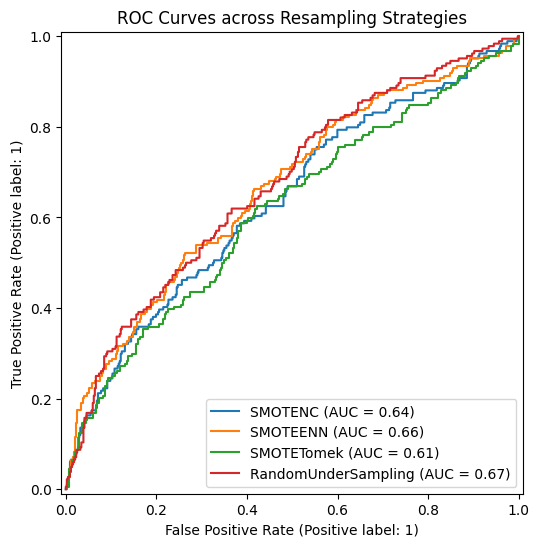

In [97]:
import catboost
cat = catboost.CatBoostClassifier(iterations=10, verbose=False)
param_grid = {
    'estimator__iterations': [500, 1000],
    'estimator__learning_rate': [0.03, 0.1],
    'estimator__depth': [4, 6, 8],
    'estimator__l2_leaf_reg': [1, 3, 5]
}

Overviewer(cat, param_grid, X_df, target, data, "f1_macro", "grid")

=== TRAIN PERFORMANCE ===
Accuracy: 0.7763975155279503

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.82      0.83      1621
           1       0.65      0.69      0.67       794

    accuracy                           0.78      2415
   macro avg       0.75      0.75      0.75      2415
weighted avg       0.78      0.78      0.78      2415

=== TEST PERFORMANCE ===
Accuracy: 0.5942028985507246

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.69      0.70       437
           1       0.33      0.38      0.35       184

    accuracy                           0.59       621
   macro avg       0.53      0.53      0.53       621
weighted avg       0.61      0.59      0.60       621



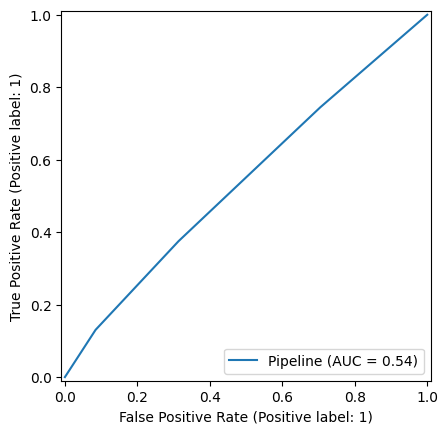

In [ ]:
groups = data["P_ID"].values
y = target.values
X = X_df.values

#split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

cols_categorical_indices = [0,1,2,3,4,5,6,7,8] #passs into smotenc

knn_pipeline = ImbPipeline([
    ('smotenc', SMOTENC(categorical_features=cols_categorical_indices, random_state=42)),
    ('scaler', StandardScaler()),
    ('estimator', KNeighborsClassifier())
])


gkf = GroupKFold(n_splits = 3)

param_grid = {
    'estimator__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'estimator__weights': ['uniform', 'distance'],        
    'estimator__metric': ['euclidean', 'manhattan']      
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv = gkf,
    scoring = "recall",
    n_jobs= -1
)

grid_search.fit(X_train, y_train, groups=groups_train)

best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

RocCurveDisplay.from_estimator(best_model, X_test, y_test)


print("=== TRAIN PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))

print("=== TEST PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))


=== TRAIN PERFORMANCE ===
Accuracy: 0.5834368530020704

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.60      0.66      1621
           1       0.40      0.54      0.46       794

    accuracy                           0.58      2415
   macro avg       0.57      0.57      0.56      2415
weighted avg       0.62      0.58      0.59      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6473429951690821

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.67      0.73       437
           1       0.43      0.60      0.50       184

    accuracy                           0.65       621
   macro avg       0.61      0.63      0.61       621
weighted avg       0.69      0.65      0.66       621



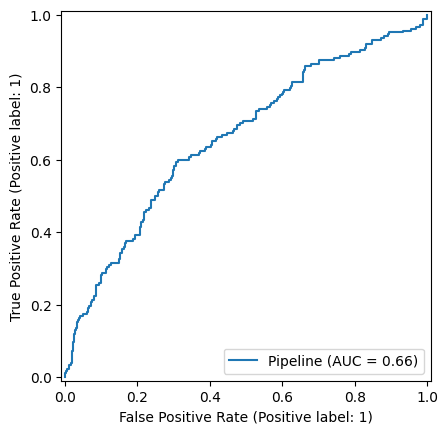

In [60]:
groups = data["P_ID"].values
y = target.values
X = X_df.values

#split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]


nb_pipeline = ImbPipeline([
    ('smotenc', SMOTENC(categorical_features=cols_categorical_indices, random_state=42)),
    ('scaler', StandardScaler()),
    ('estimator', GaussianNB())
])


gkf = GroupKFold(n_splits = 3)

param_grid = {
}

grid_search = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=param_grid,
    cv = gkf,
    scoring = "recall",
    n_jobs= -1
)

grid_search.fit(X_train, y_train, groups=groups_train)

best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

RocCurveDisplay.from_estimator(best_model, X_test, y_test)


print("=== TRAIN PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))

print("=== TEST PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))


=== TRAIN PERFORMANCE ===
Accuracy: 0.5362318840579711

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.48      0.58      1621
           1       0.38      0.66      0.48       794

    accuracy                           0.54      2415
   macro avg       0.56      0.57      0.53      2415
weighted avg       0.62      0.54      0.55      2415

=== TEST PERFORMANCE ===
Accuracy: 0.5748792270531401

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.55      0.64       437
           1       0.37      0.64      0.47       184

    accuracy                           0.57       621
   macro avg       0.58      0.59      0.56       621
weighted avg       0.66      0.57      0.59       621



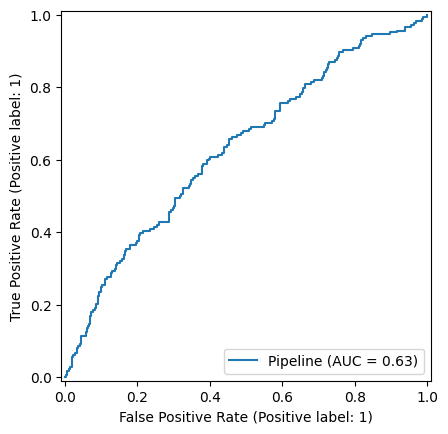

In [63]:
groups = data["P_ID"].values
y = target.values
X = X_df.values

#split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]


radial_pipeline = ImbPipeline([
    ('smotenc', SMOTENC(categorical_features=cols_categorical_indices, random_state=42)),
    ('scaler', StandardScaler()),
    ('estimator', SVC(kernel="rbf", class_weight="balanced"))
])


gkf = GroupKFold(n_splits = 3)

param_grid = {
    'estimator__C': [0.1, 1, 10, 100],
    'estimator__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]  # Dropped 0, 10, and 100
}

grid_search = GridSearchCV(
    estimator=radial_pipeline,
    param_grid=param_grid,
    cv = gkf,
    scoring = "recall",
    n_jobs= -1
)

grid_search.fit(X_train, y_train, groups=groups_train)

best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

RocCurveDisplay.from_estimator(best_model, X_test, y_test)


print("=== TRAIN PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))

print("=== TEST PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))
